In [39]:
from pathlib import Path

import numpy as np
import jax
import ml_confs
import xarray as xr

from spectraformer.input_pipeline import preprocess_dataset, preprocess_dataset_raw

jax.config.update("jax_debug_nans", True)

maindir = Path('C:/Users/dpoteryayev/1. PhD/SpectraFormer/Poisson check.ipynb').parent.resolve()

logdir = maindir / "logs"
ckptdir = maindir / "checkpoints"
# Check if logdir and ckptdir exist, if not create them
logdir.mkdir(parents=True, exist_ok=True)
ckptdir.mkdir(parents=True, exist_ok=True)

datadir = maindir / "data"

model_tag = "min8"  # CHOOSE ONE (.yaml file should exist)
                    # tag also can be found for already trained models in checkpoints folder

configsdir = maindir / "configs"
configsdir.mkdir(parents=True, exist_ok=True)

config_file_name = f"configs_{model_tag}.yaml"
config_file_path = configsdir / config_file_name

configs = ml_confs.from_file(config_file_path)
configs.tabulate()

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Key                    ┃ Value              ┃ Type      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ tag                    │ spectraformer:min8 │ str       │
│ embedding_dim          │ 64                 │ int       │
│ num_heads              │ 8                  │ int       │
│ num_layers             │ 2                  │ int       │
│ learning_rate          │ 0.0001             │ float     │
│ num_epochs             │ 600                │ int       │
│ batch_size             │ 19                 │ int       │
│ dropout_rate           │ 0.5                │ float     │
│ root_rng_seed          │ 0                  │ int       │
│ train_dataset          │ SiC_19x10x3        │ str       │
│ log_every_epochs       │ 5                  │ int       │
│ masked_interval_starts │ [1000, 2500]       │ list[int] │
│ masked_interval_ends   │ [1700, 2900]       │ list[int] │
└────────────────────────┴────────────────────┴───────────┘

In [40]:
# Load the full dataset
full_ds = preprocess_dataset(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc")
)
full_ds

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[ 0.04293261,  0.04625452,  0.04969184, ...,  0.05316029,
         0.05920229,  0.05718747],
       [ 0.05792249,  0.04627183,  0.05345624, ...,  0.04511093,
         0.05768641,  0.04946516],
       [ 0.05249544,  0.04628915,  0.04411285, ...,  0.05185167,
         0.05924303,  0.04561219],
       ...,
       [ 0.00072521, -0.00108472, -0.01303295, ...,  0.00743335,
        -0.00301884, -0.01105804],
       [-0.00777138,  0.00459732, -0.01068912, ...,  0.00576082,
         0.0008249 , -0.01347082],
       [-0.01117231, -0.00675478, -0.00835022, ..., -0.00095763,
        -0.00493221,  0.00829474]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

In [41]:
mean_values = np.mean(full_ds, axis=1)
variance_values = np.var(full_ds, axis=1)
std_values = np.std(full_ds, axis=1)

print("Mean values:", mean_values)
print("Variance values:", variance_values)

Mean values: <xarray.DataArray (wave_number: 1015)>
array([ 0.04949382,  0.05288047,  0.05428554, ..., -0.00444253,
       -0.00444292, -0.00444421])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Variance values: <xarray.DataArray (wave_number: 1015)>
array([8.41879387e-05, 8.30354414e-05, 7.73234507e-05, ...,
       5.51897148e-05, 5.03860503e-05, 5.09126582e-05])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


In [42]:
import matplotlib.pyplot as plt

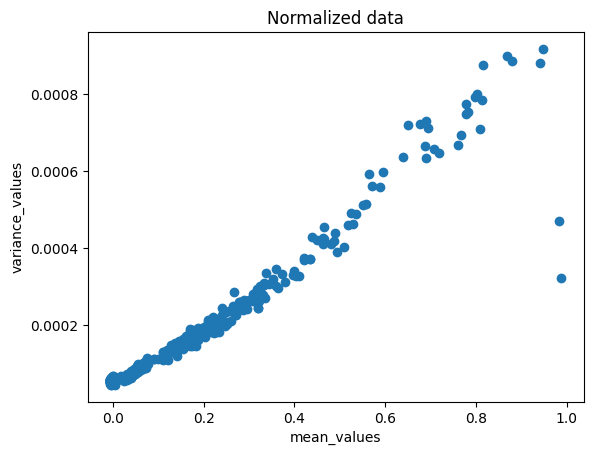

In [43]:
fig, ax = plt.subplots()
ax.scatter(x=mean_values, y=variance_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('variance_values')
ax.set_title('Normalized data')
plt.show()

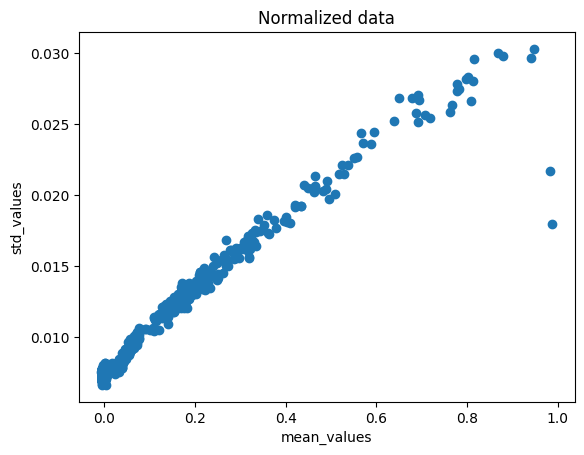

In [44]:
fig, ax = plt.subplots()
ax.scatter(x=mean_values, y=std_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('std_values')
ax.set_title('Normalized data')
plt.show()

(array([7.00000e+00, 7.00000e+01, 2.51200e+03, 3.60760e+04, 1.53424e+05,
        1.32459e+05, 2.12340e+04, 7.80600e+03, 1.20910e+04, 1.47720e+04,
        1.47420e+04, 1.10140e+04, 6.12200e+03, 2.46600e+03, 1.85700e+03,
        2.62600e+03, 3.68900e+03, 5.20400e+03, 7.79000e+03, 1.16450e+04,
        1.51450e+04, 1.62730e+04, 1.26530e+04, 8.12100e+03, 6.09700e+03,
        5.41000e+03, 4.99800e+03, 3.98100e+03, 3.20000e+03, 2.64200e+03,
        2.28400e+03, 2.19000e+03, 2.16000e+03, 2.18600e+03, 2.50400e+03,
        2.46800e+03, 2.18000e+03, 1.78700e+03, 1.32300e+03, 1.04800e+03,
        9.50000e+02, 7.98000e+02, 8.88000e+02, 8.65000e+02, 9.66000e+02,
        9.23000e+02, 9.40000e+02, 9.69000e+02, 9.82000e+02, 9.22000e+02,
        9.20000e+02, 9.03000e+02, 8.56000e+02, 8.12000e+02, 7.37000e+02,
        7.57000e+02, 6.82000e+02, 6.60000e+02, 6.05000e+02, 5.42000e+02,
        4.93000e+02, 3.81000e+02, 3.10000e+02, 2.56000e+02, 2.83000e+02,
        3.01000e+02, 3.56000e+02, 3.99000e+02, 4.93

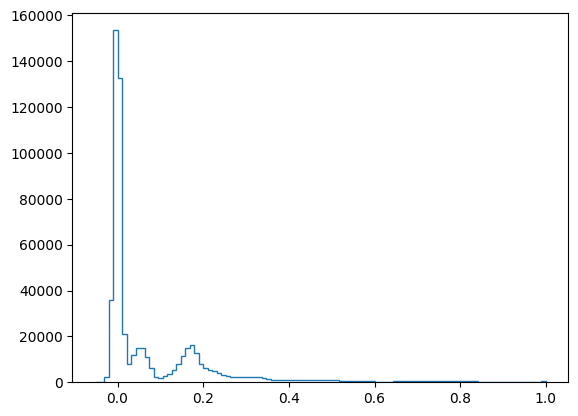

In [45]:
full_ds.plot.hist(bins=100, histtype='step')

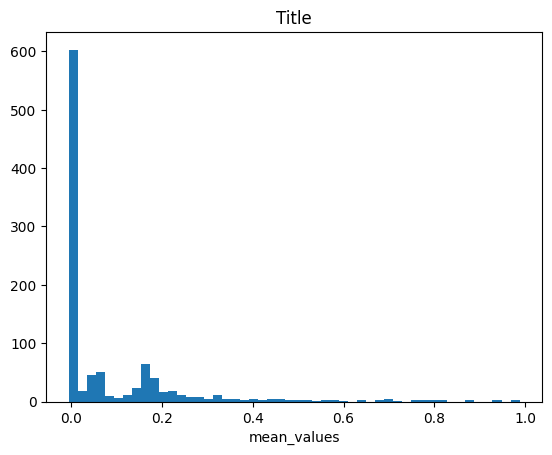

In [46]:
fig, ax = plt.subplots()
ax.hist(mean_values, bins=50)
ax.set_xlabel('mean_values')
ax.set_title('Title')
plt.show()

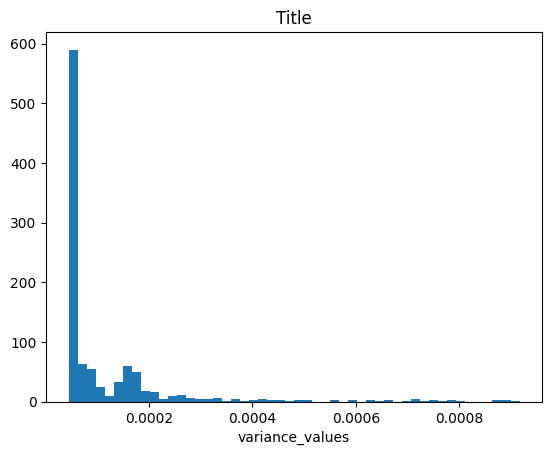

In [47]:
fig, ax = plt.subplots()
ax.hist(variance_values, bins=50)
ax.set_xlabel('variance_values')
ax.set_title('Title')
plt.show()

In [48]:
raw_ds = preprocess_dataset_raw(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc"), raw = True
)
raw_ds

<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[ 46.380779,  44.910511,  39.02943 , ...,  58.142941,  56.672665,
         43.440235],
       [ 62.574589,  44.927311,  41.986103, ...,  49.33913 ,  55.221554,
         37.574284],
       [ 56.711666,  44.944126,  34.64753 , ...,  56.711666,  56.711666,
         34.64753 ],
       ...,
       [  0.783453,  -1.0532  , -10.236464, ...,   8.130066,  -2.889853,
         -8.399811],
       [ -8.395548,   4.463737,  -8.395548, ...,   6.300777,   0.789656,
        -10.232588],
       [-12.069628,  -6.558508,  -6.558508, ...,  -1.047386,  -4.721466,
          6.300777]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

In [49]:
raw_mean_values = np.mean(raw_ds, axis=1)
raw_variance_values = np.var(raw_ds, axis=1)
raw_std_values = np.std(raw_ds, axis=1)

print("Raw Mean values:", mean_values)
print("Raw Variance values:", variance_values)

Raw Mean values: <xarray.DataArray (wave_number: 1015)>
array([ 0.04949382,  0.05288047,  0.05428554, ..., -0.00444253,
       -0.00444292, -0.00444421])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Raw Variance values: <xarray.DataArray (wave_number: 1015)>
array([8.41879387e-05, 8.30354414e-05, 7.73234507e-05, ...,
       5.51897148e-05, 5.03860503e-05, 5.09126582e-05])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03


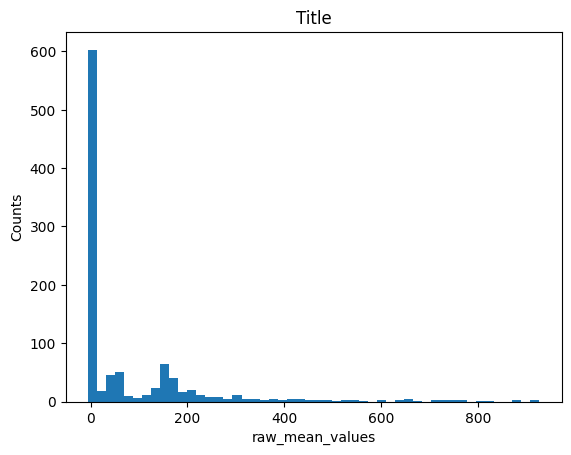

In [50]:
fig, ax = plt.subplots()
ax.hist(raw_mean_values, bins=50)
ax.set_xlabel('raw_mean_values')
ax.set_ylabel('Counts')
ax.set_title('Title')
plt.show()

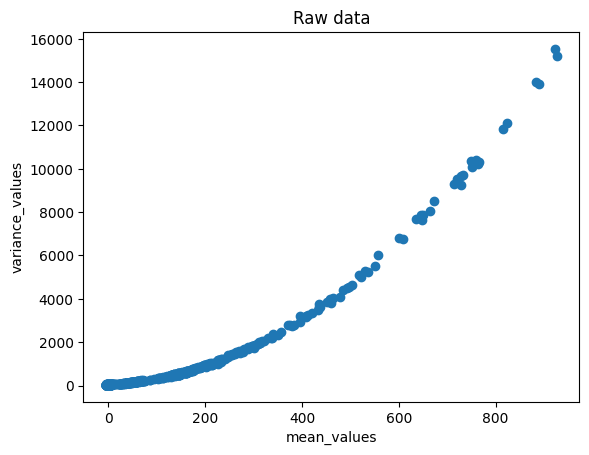

In [51]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_variance_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('variance_values')
ax.set_title('Raw data')
plt.show()

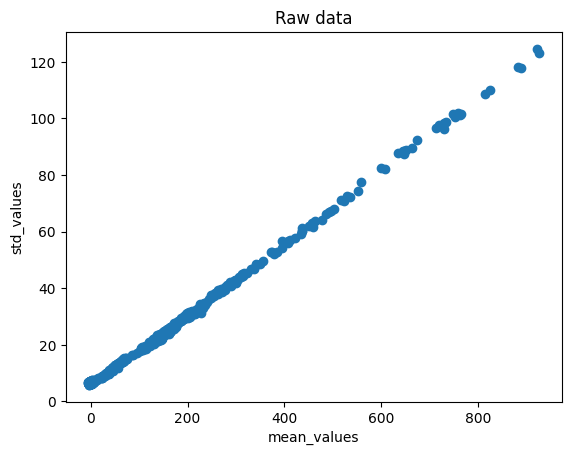

In [52]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_std_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('std_values')
ax.set_title('Raw data')
plt.show()

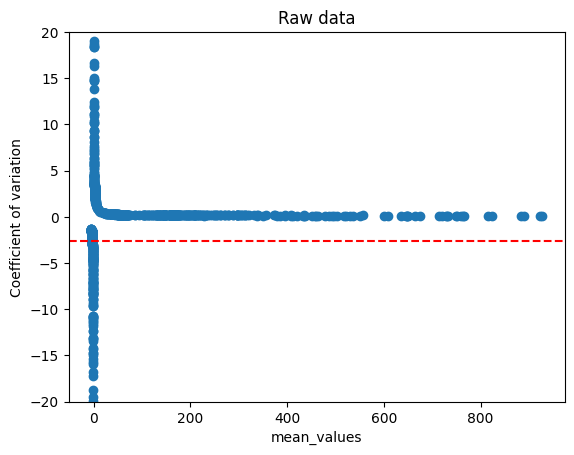

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_std_values/raw_mean_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('Coefficient of variation')
ax.set_title('Raw data')
ax.set_ylim([-20, 20])
ax.axhline(y=np.mean(raw_std_values/raw_mean_values), color='r', linestyle='--')
plt.show()

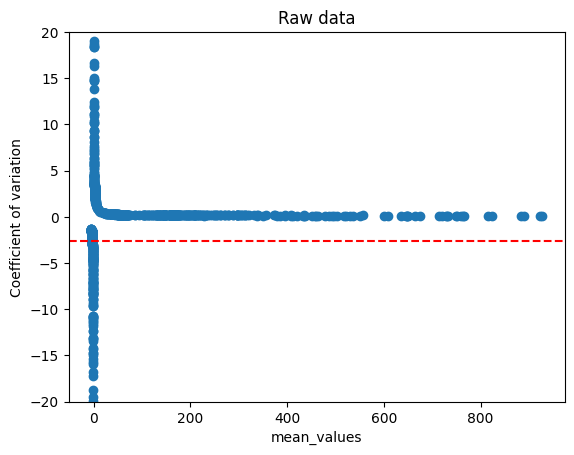

In [76]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_std_values/raw_mean_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('Coefficient of variation')
ax.set_title('Raw data')
ax.set_ylim([-20, 20])
ax.axhline(y=np.mean(raw_std_values/raw_mean_values), color='r', linestyle='--')
plt.show()

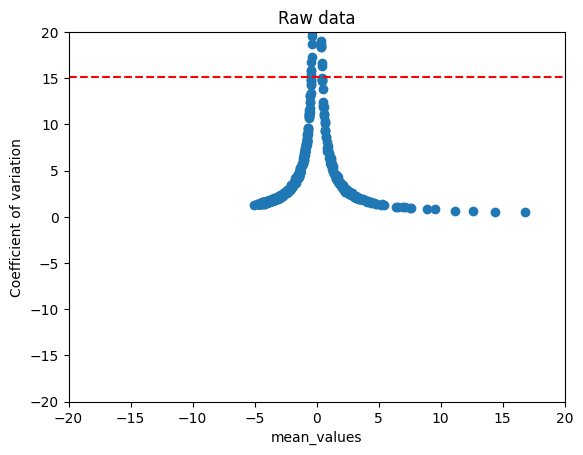

In [74]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=np.abs(raw_std_values)/np.abs(raw_mean_values))
ax.set_xlabel('mean_values')
ax.set_ylabel('Coefficient of variation')
ax.set_title('Raw data')
ax.set_xlim([-20, 20])
ax.set_ylim([-20, 20])
ax.axhline(y=np.mean(raw_std_values/np.abs(raw_mean_values)), color='r', linestyle='--')
plt.show()

In [66]:
np.mean(raw_std_values/np.abs(raw_mean_values))

<xarray.DataArray ()>
np.float64(15.142784076828159)

In [70]:
# Shape parameter k=mean^2/variance^2
raw_param_k_values = raw_mean_values**2/raw_variance_values**2
print(raw_param_k_values)
print(raw_param_k_values.mean())

<xarray.DataArray (wave_number: 1015)>
array([0.1065357 , 0.10699556, 0.11422943, ..., 0.00791666, 0.00990257,
       0.00965966])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
<xarray.DataArray ()>
np.float64(0.030051516412143663)


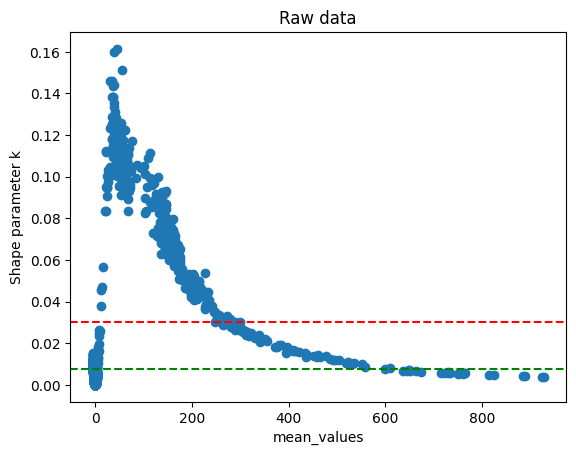

In [77]:
fig, ax = plt.subplots()
ax.scatter(x=raw_mean_values, y=raw_param_k_values)
ax.set_xlabel('mean_values')
ax.set_ylabel('Shape parameter k')
ax.set_title('Raw data')
# ax.set_xlim([-20, 20])
# ax.set_ylim([-20, 20])
ax.axhline(y=raw_param_k_values.mean(), color='r', linestyle='--')
ax.axhline(y=raw_param_k_values.median(), color='g', linestyle='--')

plt.show()